<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/MACHINE-LEARNING-EXERCISES/blob/main/Exercise_12_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

df = pd.read_csv("EFIplus_medit.csv", sep=";")

In [6]:
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df.columns.tolist()

['Site_code',
 'Latitude',
 'Longitude',
 'Country',
 'Catchment_name',
 'Galiza',
 'Subsample',
 'Calib_EFI_Medit',
 'Calib_connect',
 'Calib_hydrol',
 'Calib_morphol',
 'Calib_wqual',
 'Geomorph1',
 'Geomorph2',
 'Geomorph3',
 'Water_source_type',
 'Flow_regime',
 'Altitude',
 'Geological_typology',
 'Actual_river_slope',
 'Natural_sediment',
 'Elevation_mean_catch',
 'prec_ann_catch',
 'temp_ann',
 'temp_jan',
 'temp_jul',
 'Barriers_catchment_down',
 'Barriers_river_segment_up',
 'Barriers_river_segment_down',
 'Barriers_number_river_segment_up',
 'Barriers_number_river_segment_down',
 'Barriers_distance_river_segment_up',
 'Barriers_distance_river_segment_down',
 'Impoundment',
 'Hydropeaking',
 'Water_abstraction',
 'Hydro_mod',
 'Temperature_impact',
 'Velocity_increase',
 'Reservoir_flushing',
 'Sedimentation',
 'Channelisation',
 'Cross_sec',
 'Instream_habitat',
 'Riparian_vegetation',
 'Embankment',
 'Floodprotection',
 'Floodplain',
 'Toxic_substances',
 'Acidification',
 '

In [8]:
df["Catchment_name"].unique()

array(['Guadalquivir', 'Tejo', 'Douro', 'Segura', 'Jucar', 'Ebro',
       'Cantabrica', 'Guadia', 'Jucar-Ebro', 'Sur', 'Galiza-Norte',
       'Minho', 'Galiza-Sul', 'Catala', 'Segura-Jucar', 'Garonne',
       'Rhone', 'South_France_E', 'South_France_W', 'Corse',
       'Ombrone-Tevere', 'Campania-South', 'Tevere', 'Arno-Ombrone',
       'Italia-Veneto', 'Sardinia', 'Ombrone', 'Saline-Pescara-Sangro',
       'Oeste', 'Mira', 'Mondego', 'Odelouca', 'Algarve-Sotavento',
       'Algarve-barlavento', 'Sado', 'Tejo-Sado', 'Vouga',
       'EntreDouroeVouga', 'Vouga-Mondego'], dtype=object)

In [9]:
basins = ["Douro", "Tejo", "Mondego", "Minho"]

df_lda = df[df["Catchment_name"].isin(basins)]

In [10]:
env_vars = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

X = df_lda[env_vars]
y = df_lda['Catchment_name']

In [11]:
data = pd.concat([X, y], axis=1).dropna()

X = data[env_vars]
y = data['Catchment_name']

In [12]:
print(X.shape)
print(y.shape)

(1681, 7)
(1681,)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

X_lda = lda.fit_transform(X_scaled, y)

In [15]:
X_lda.shape

(1681, 3)

In [16]:
lda_df = pd.DataFrame(
    X_lda,
    columns=["LD1", "LD2", "LD3"]
)

lda_df["Catchment_name"] = y.values

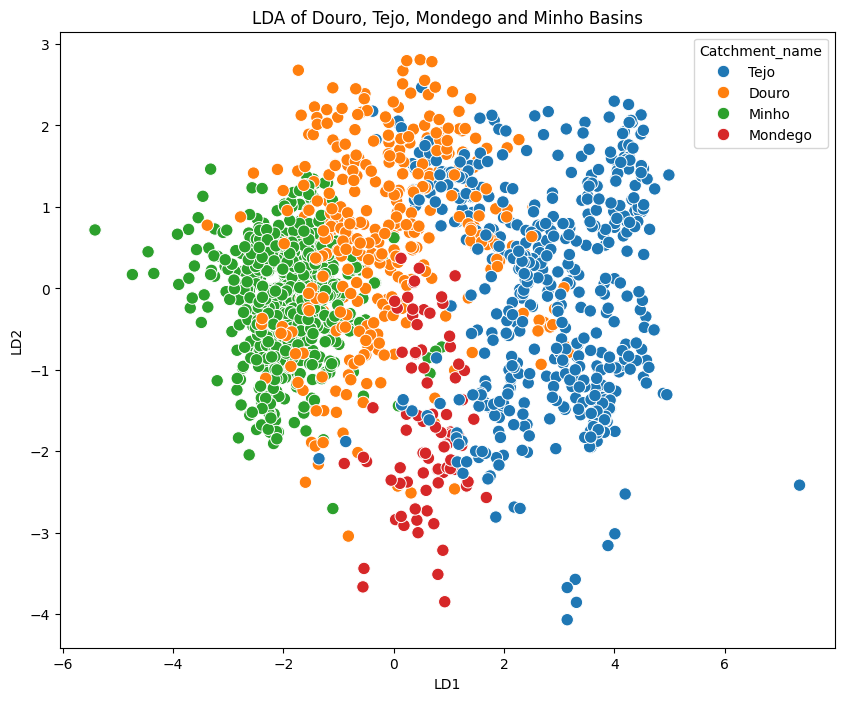

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=lda_df,
    x="LD1",
    y="LD2",
    hue="Catchment_name",
    s=80
)

plt.title("LDA of Douro, Tejo, Mondego and Minho Basins")
plt.show()

In [18]:
loadings = pd.DataFrame(
    lda.scalings_,
    index=env_vars
)

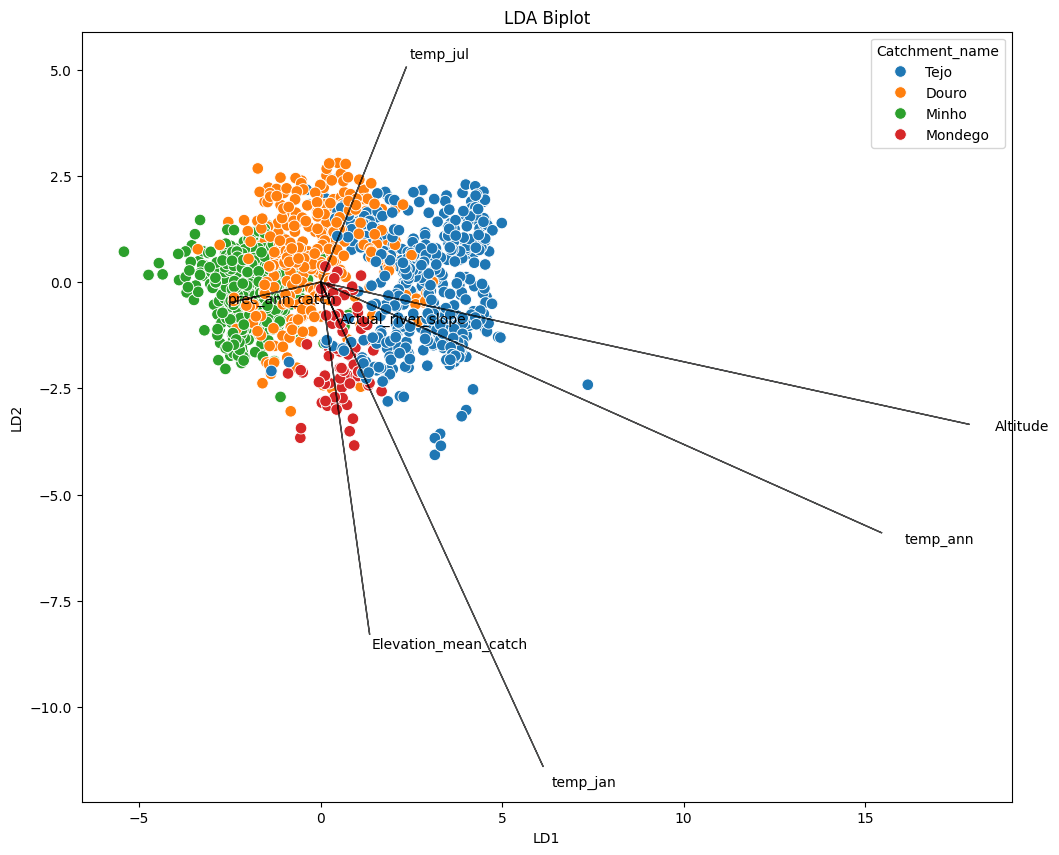

In [19]:
plt.figure(figsize=(12,10))

sns.scatterplot(
    data=lda_df,
    x="LD1",
    y="LD2",
    hue="Catchment_name",
    s=70
)

for variable in env_vars:
    plt.arrow(
        0, 0,
        loadings.loc[variable, 0] * 5,
        loadings.loc[variable, 1] * 5,
        alpha=0.7
    )

    plt.text(
        loadings.loc[variable, 0] * 5.2,
        loadings.loc[variable, 1] * 5.2,
        variable
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Biplot")
plt.show()

In [20]:
lda.explained_variance_ratio_

array([0.90620956, 0.05732636, 0.03646408])

In [21]:
import plotly.express as px

fig = px.scatter(
    lda_df,
    x="LD1",
    y="LD2",
    color="Catchment_name",
    hover_name="Catchment_name",
    title="Interactive LDA Plot"
)

fig.show()

In [22]:
lda.explained_variance_ratio_

array([0.90620956, 0.05732636, 0.03646408])

### Interpretation of the Linear Discriminant Analysis

The Linear Discriminant Analysis generated three discriminant functions because four catchments (Douro, Tejo, Mondego and Minho) were used as predefined groups. The proportion of variance explained by each discriminant function was:

* LD1 = 90.62%
* LD2 = 5.73%
* LD3 = 3.65%

The first discriminant function (LD1) accounted for the vast majority of the discrimination among catchments, explaining more than 90% of the variation. This indicates that most of the environmental differences among the four river basins are represented along a single environmental gradient. Consequently, the horizontal separation of sites in the LD1–LD2 biplot is the main factor distinguishing the catchments.

The second discriminant function (LD2) explained only 5.73% of the variation, indicating that it contributes relatively little additional information beyond LD1. The third discriminant function (LD3) explained only 3.65% of the variation and therefore has a minor role in differentiating the catchments.

Together, LD1 and LD2 explain approximately 96.35% of the total discriminatory information. This means that the two-dimensional biplot provides an excellent representation of the separation among the Douro, Tejo, Mondego and Minho catchments, with very little information lost by not displaying LD3.

Overall, the results suggest that the selected environmental variables are effective in discriminating among the four river basins and that the primary environmental differences among catchments are concentrated along a single dominant gradient represented by LD1.


In [23]:
loadings

,0,1,2
Altitude,3.573123,-0.669434,-0.845274
Actual_river_slope,0.100684,-0.185863,0.180732
Elevation_mean_catch,0.269917,-1.658257,0.693442
prec_ann_catch,-0.490044,-0.094427,-1.018535
temp_ann,3.091315,-1.180445,-6.112674
temp_jan,1.225809,-2.280906,4.653993
temp_jul,0.472179,1.013711,1.667523


### Results and Interpretation of the Linear Discriminant Analysis

A Linear Discriminant Analysis (LDA) was performed using seven environmental variables (Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan and temp_jul) to discriminate among the Douro, Tejo, Mondego and Minho catchments.

The analysis generated three discriminant functions. The first discriminant function (LD1) explained 90.62% of the total discriminatory variation, while LD2 and LD3 explained only 5.73% and 3.65%, respectively. Therefore, most of the separation among catchments is represented along LD1, indicating that a single dominant environmental gradient differentiates the four basins.

The variables with the largest contributions to LD1 were Altitude (3.57), annual temperature (temp_ann = 3.09) and January temperature (temp_jan = 1.23). These results indicate that differences in elevation and thermal conditions are the primary factors responsible for distinguishing the catchments. In contrast, river slope, mean catchment elevation and summer temperature contributed less strongly to the main discriminant axis.

Annual precipitation showed a negative loading on LD1 (-0.49), suggesting an inverse relationship with the dominant environmental gradient. Catchments located on opposite sides of LD1 therefore differ not only in temperature and altitude but also in precipitation characteristics.

Because LD1 alone explains more than 90% of the discrimination, the LD1–LD2 biplot provides an excellent representation of the environmental differences among the four river basins. The relatively small contribution of LD2 and LD3 indicates that additional environmental gradients play only a minor role in separating the catchments.

Overall, the results demonstrate that environmental variables successfully discriminate among the Douro, Tejo, Mondego and Minho catchments, with altitude and temperature emerging as the most influential factors driving basin differentiation.
